In [4]:
import sys
print(sys.executable)
print(sys.version)
!{sys.executable} -m pip install opencv-python torch pandas


c:\Users\Admin\AppData\Local\Programs\Python\Python312\python.exe
3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



  Using cached opencv_python-4.13.0.90-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached numpy-2.4.1-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
Using cached opencv_python-4.13.0.90-cp37-abi3-win_amd64.whl (40.2 MB)
Using cached numpy-2.4.1-cp312-cp312-win_amd64.whl (12.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.3
    Uninstalling numpy-1.26.3:
      Successfully uninstalled numpy-1.26.3


In [6]:
import os
import cv2
import torch
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [7]:
# Dataset PyTorch pour eyetracking

class EyeTrackingDataset(Dataset):
    def __init__(self, csv_file, img_dir, img_size=(224,224), transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.img_size = img_size
        self.transform = transform

        # filtrer les lignes où l'image existe et est valide
        valid_indices = []
        for idx, row in self.df.iterrows():
            fid = int(row['frame_id'])
            img_path = os.path.join(img_dir, f"frame_{fid:04d}.png")
            if os.path.exists(img_path):
                img = cv2.imread(img_path)
                if img is not None and len(img.shape) == 3 and img.shape[0] > 0 and img.shape[1] > 0:
                    valid_indices.append(idx)
        self.df = self.df.iloc[valid_indices].reset_index(drop=True)

        # créer mapping frame_id -> image path
        self.img_paths = [os.path.join(img_dir, f"frame_{int(fid):04d}.png") 
                          for fid in self.df['frame_id']]

        # extraire les coordonnées
        self.coords = self.df[['x','y']].values.astype(np.float32)

        # Calculer les maxima pour normalisation
        self.max_x = 1272 #np.max(self.coords[:, 0])
        self.max_y = 712 #np.max(self.coords[:, 1])

        # Normaliser toutes les coordonnées
        self.coords[:, 0] /= self.max_x
        self.coords[:, 1] /= self.max_y
        

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = cv2.imread(img_path)
        if img.ndim == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        elif img.shape[2] == 1:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # resize
        img = cv2.resize(img, self.img_size)

        # coordonnées déjà normalisées
        x, y = self.coords[idx]
        label = torch.tensor([x, abs(y)], dtype=torch.float32)

        # transform PyTorch (ToTensor + normalisation)
        if self.transform:
            img = self.transform(img)
        else:
            # default transform
            img = transforms.ToTensor()(img)
            img = transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])(img)

        return img, label

In [8]:
# (FIX) Chemins locaux + split automatique
from torch.utils.data import random_split

base_dir = os.getcwd()
csv_file = os.path.join(base_dir, "data", "coords_20260121_082431.csv")
img_dir = os.path.join(base_dir, "data", "frames")

full_dataset = EyeTrackingDataset(csv_file, img_dir)
total_size = len(full_dataset)
if total_size == 0:
    raise ValueError("Dataset vide: vérifie data/frames et le CSV.")

train_size = int(0.7 * total_size)
dev_size = int(0.15 * total_size)
test_size = total_size - train_size - dev_size
generator = torch.Generator().manual_seed(42)
train_dataset, dev_dataset, test_dataset = random_split(
    full_dataset, [train_size, dev_size, test_size], generator=generator
 )

print(f"Train size: {len(train_dataset)}")
print(f"Dev size: {len(dev_dataset)}")
print(f"Test size: {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

imgs, labels = next(iter(train_loader))
print(imgs.shape, labels.shape)  # imgs: [B,3,H,W], labels: [B,2]

Train size: 1249
Dev size: 267
Test size: 269
torch.Size([32, 3, 224, 224]) torch.Size([32, 2])


In [9]:
print(full_dataset.max_x, full_dataset.max_y)

1272 712


In [10]:
# Définition du modèle CNN pour prédiction du regard
import torch.nn as nn

class GazeNet(nn.Module):
    def __init__(self):
        super(GazeNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(4, 4)
        self.fc1 = nn.Linear(6272, 256)
        self.fc2 = nn.Linear(256, 2)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.shape[0], -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

model = GazeNet()
print("number of parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


number of parameters: 1611490


In [11]:

import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 20  

In [18]:
# Comparaison avec un modèle aléatoire (non entraîné)

random_model = GazeNet()  

random_model.eval()
random_test_loss = 0.0
random_preds = []
random_labels = []
with torch.no_grad():
    for imgs, labels in test_loader:
        outputs = random_model(imgs)
        loss = criterion(outputs, labels)
        random_test_loss += loss.item()
        random_preds.append(outputs.cpu())
        random_labels.append(labels.cpu())

random_preds = torch.cat(random_preds)
random_labels = torch.cat(random_labels)

random_mae = torch.mean(torch.abs(random_preds - random_labels)).item()
random_rmse = torch.sqrt(torch.mean((random_preds - random_labels)**2)).item()

# Accuracy pour random
random_distances = torch.sqrt(torch.sum((random_preds - random_labels)**2, dim=1))
random_accuracy = (random_distances < 0.1).float().mean().item() * 100

print(f"Test Loss du modèle aléatoire (MSE): {random_test_loss/len(test_loader):.4f}")
print(f"Test MAE du modèle aléatoire: {random_mae:.4f}")
print(f"Test RMSE du modèle aléatoire: {random_rmse:.4f}")


Test Loss du modèle aléatoire (MSE): 0.0773
Test MAE du modèle aléatoire: 0.2350
Test RMSE du modèle aléatoire: 0.2793


In [12]:
# Pour stocker les pertes et accuracies
train_losses = []
val_losses = []
train_maes = []
val_maes = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_mae = 0.0
    count = 0
    for imgs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        mae = torch.mean(torch.abs(outputs - labels)).item()
        running_mae += mae
        count += 1
    
    train_loss = running_loss / count
    train_mae = running_mae / count
    train_losses.append(train_loss)
    train_maes.append(train_mae)
    
    # Validation
    model.eval()
    val_loss = 0.0
    val_mae = 0.0
    count = 0
    with torch.no_grad():
        for imgs, labels in dev_loader:
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            mae = torch.mean(torch.abs(outputs - labels)).item()
            val_mae += mae
            count += 1
    
    val_loss = val_loss / count
    val_mae = val_mae / count
    val_losses.append(val_loss)
    val_maes.append(val_mae)
    
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train MAE: {train_mae:.4f}, Val Loss: {val_loss:.4f}, Val MAE: {val_mae:.4f}")

print("Entraînement terminé.")

Epoch 1/20, Train Loss: 0.0446, Train MAE: 0.1673, Val Loss: 0.0418, Val MAE: 0.1460
Epoch 2/20, Train Loss: 0.0295, Train MAE: 0.1213, Val Loss: 0.0258, Val MAE: 0.1055
Epoch 3/20, Train Loss: 0.0233, Train MAE: 0.1059, Val Loss: 0.0230, Val MAE: 0.0982
Epoch 4/20, Train Loss: 0.0193, Train MAE: 0.0937, Val Loss: 0.0202, Val MAE: 0.0928
Epoch 5/20, Train Loss: 0.0165, Train MAE: 0.0848, Val Loss: 0.0171, Val MAE: 0.0868
Epoch 6/20, Train Loss: 0.0129, Train MAE: 0.0754, Val Loss: 0.0157, Val MAE: 0.0810
Epoch 7/20, Train Loss: 0.0116, Train MAE: 0.0710, Val Loss: 0.0142, Val MAE: 0.0780
Epoch 8/20, Train Loss: 0.0107, Train MAE: 0.0665, Val Loss: 0.0145, Val MAE: 0.0770
Epoch 9/20, Train Loss: 0.0097, Train MAE: 0.0644, Val Loss: 0.0122, Val MAE: 0.0703
Epoch 10/20, Train Loss: 0.0095, Train MAE: 0.0627, Val Loss: 0.0107, Val MAE: 0.0670
Epoch 11/20, Train Loss: 0.0083, Train MAE: 0.0595, Val Loss: 0.0103, Val MAE: 0.0671
Epoch 12/20, Train Loss: 0.0082, Train MAE: 0.0594, Val Loss: 0

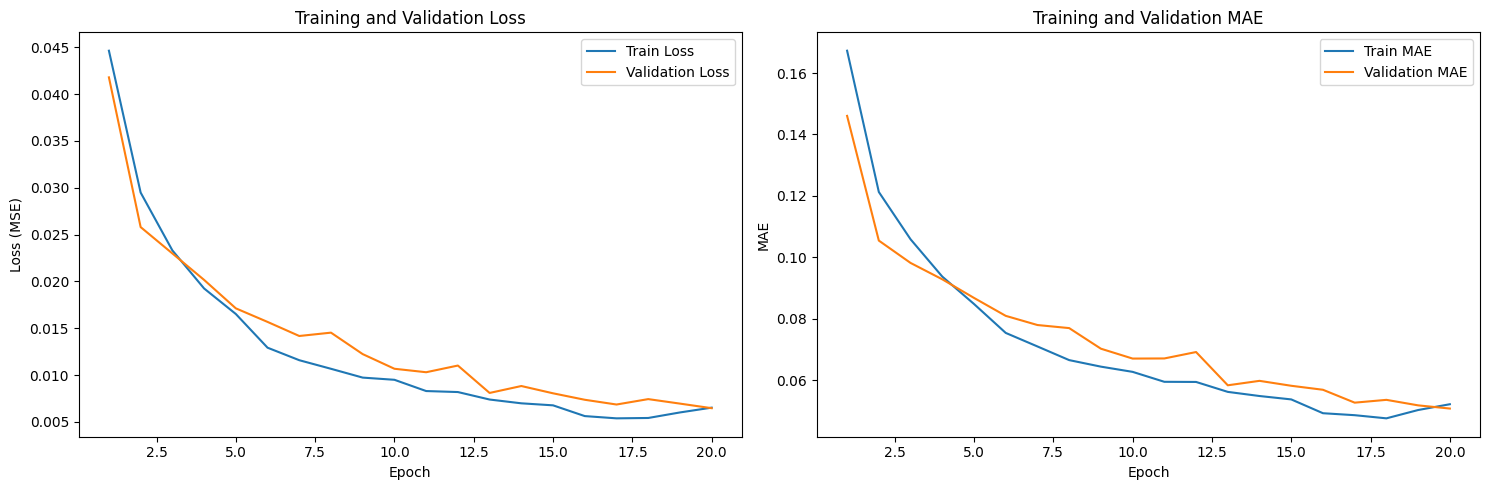

In [13]:
# Affichage des courbes de perte et MAE
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Courbes de Loss
ax1.plot(epochs, train_losses, label='Train Loss')
ax1.plot(epochs, val_losses, label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Training and Validation Loss')
ax1.legend()

# Courbes de MAE
ax2.plot(epochs, train_maes, label='Train MAE')
ax2.plot(epochs, val_maes, label='Validation MAE')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.set_title('Training and Validation MAE')
ax2.legend()

plt.tight_layout()
plt.show()

In [15]:
model.eval()
test_loss = 0.0
preds = []
labels = []
with torch.no_grad():
    for imgs, labs in test_loader:
        outputs = model(imgs)
        loss = criterion(outputs, labs)
        test_loss += loss.item()
        preds.append(outputs.cpu())
        labels.append(labs.cpu())

preds = torch.cat(preds)
labels = torch.cat(labels)

mae = torch.mean(torch.abs(preds - labels)).item()
rmse = torch.sqrt(torch.mean((preds - labels)**2)).item()

# Accuracy pour le modèle entraîné
distances = torch.sqrt(torch.sum((preds - labels)**2, dim=1))
accuracy = (distances < 0.1).float().mean().item() * 100

print(f"Test Loss (MSE): {test_loss/len(test_loader):.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test Accuracy (dist < 0.1): {accuracy:.2f}%")

# Sauvegarder le modèle
import os
model_path = os.path.join('data', 'gaze_model_trained.pth')
torch.save(model.state_dict(), model_path)
print(f"Modèle sauvegardé dans {model_path}.")

Test Loss (MSE): 0.0062
Test MAE: 0.0523
Test RMSE: 0.0797
Test Accuracy (dist < 0.1): 64.31%
Modèle sauvegardé dans data\gaze_model_trained.pth.


Center predictor — MSE: 0.0833, MAE: 0.2454, RMSE: 0.2886, Acc(dist<0.1): 5.58%
Mean predictor  — MSE: 0.0565, MAE: 0.1957, RMSE: 0.2376, Acc(dist<0.1): 6.69%
Uniform random  — MSE: 0.1729, MAE: 0.3436, RMSE: 0.4158, Acc(dist<0.1): 4.46%
Random model outputs mean: [0.52367043 0.5093381 ] std: [0.00143882 0.00075047]
Labels stats (norm) x -> mean: 0.7314, std: 0.1529, min: 0.4803, max: 0.9992
Labels stats (norm) y -> mean: 0.4882, std: 0.2993, min: 0.0098, max: 1.0000


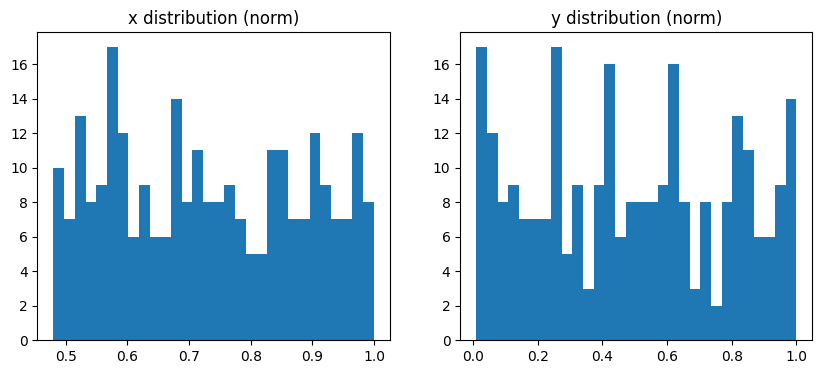

MAE en pixels (center): 243.40px
MAE en pixels (mean): 194.18px
MAE en pixels (uniform random): 340.86px
MAE en pixels (modèle entraîné): 51.88px


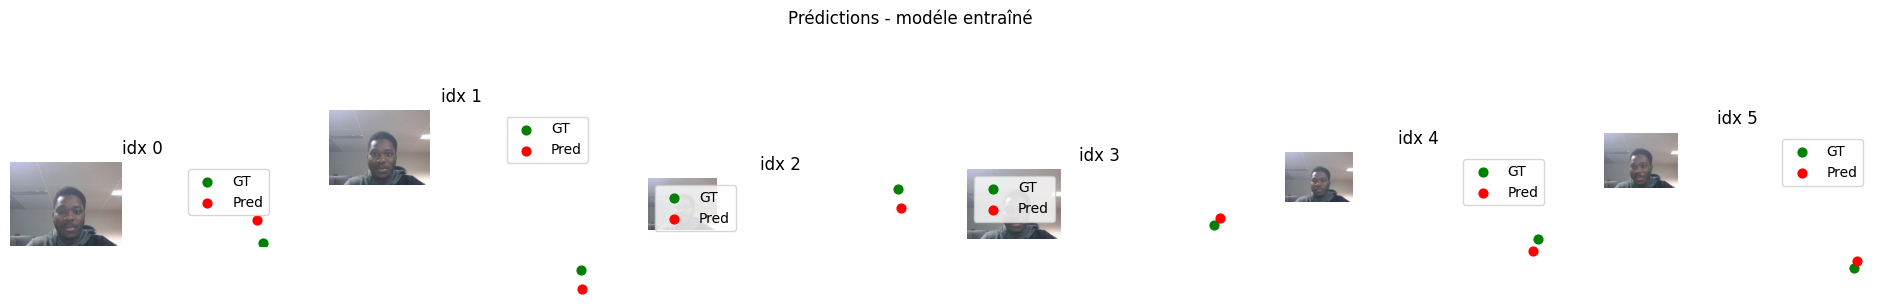

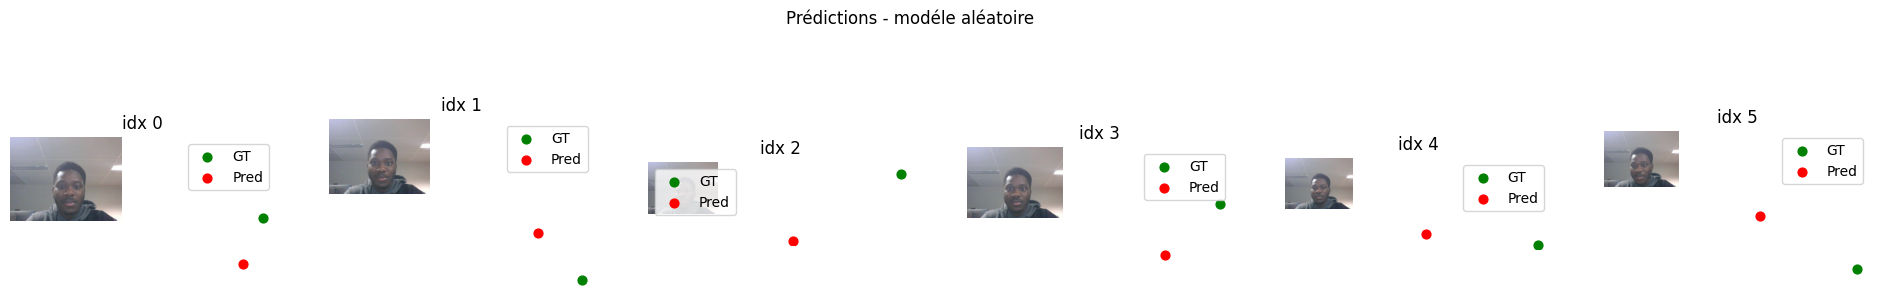


Diagnostics terminés. Recommande: retirer abs(y) si inutile, et comparer les baselines (center/mean) aux performances actuelles.


In [19]:
# Diagnostics supplémentaires — baselines, distribution, vérifications et visualisations
# - Calcule des baselines (center / mean / uniform random)
# - Inspecte la distribution des labels (normalisés)
# - Vérifie la moyenne/écart-type des sorties du modèle aléatoire
# - Affiche des overlays (GT vs prédictions) pour le modèle entraîné et le modèle aléatoire

import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2

# helper pour évaluer un prédicteur sur un DataLoader
def eval_predictor(predict_fn, loader):
    preds = []
    labels = []
    with torch.no_grad():
        for imgs, labs in loader:
            p = predict_fn(imgs)
            preds.append(p.cpu())
            labels.append(labs.cpu())
    preds = torch.cat(preds)
    labels = torch.cat(labels)
    mse = torch.mean((preds - labels)**2).item()
    mae = torch.mean(torch.abs(preds - labels)).item()
    rmse = torch.sqrt(torch.mean((preds - labels)**2)).item()
    distances = torch.sqrt(torch.sum((preds - labels)**2, dim=1))
    acc = (distances < 0.1).float().mean().item() * 100
    return {'mse': mse, 'mae': mae, 'rmse': rmse, 'acc': acc, 'preds': preds, 'labels': labels}

# Center predictor (prévoit [0.5,0.5])
def center_predictor(imgs):
    b = imgs.shape[0]
    return torch.full((b,2), 0.5)

center_res = eval_predictor(lambda imgs: center_predictor(imgs), test_loader)
print("Center predictor — MSE: {:.4f}, MAE: {:.4f}, RMSE: {:.4f}, Acc(dist<0.1): {:.2f}%".format(center_res['mse'], center_res['mae'], center_res['rmse'], center_res['acc']))

# Mean predictor (moyenne des labels du test)
all_test_labels = torch.cat([labs for _, labs in test_loader])
mean_label = torch.mean(all_test_labels, dim=0)
def mean_predictor(imgs):
    b = imgs.shape[0]
    return mean_label.unsqueeze(0).repeat(b,1)

mean_res = eval_predictor(lambda imgs: mean_predictor(imgs), test_loader)
print("Mean predictor  — MSE: {:.4f}, MAE: {:.4f}, RMSE: {:.4f}, Acc(dist<0.1): {:.2f}%".format(mean_res['mse'], mean_res['mae'], mean_res['rmse'], mean_res['acc']))

# Uniform random predictor
def uniform_random_predictor(imgs):
    return torch.rand(imgs.shape[0],2)

rand_res = eval_predictor(lambda imgs: uniform_random_predictor(imgs), test_loader)
print("Uniform random  — MSE: {:.4f}, MAE: {:.4f}, RMSE: {:.4f}, Acc(dist<0.1): {:.2f}%".format(rand_res['mse'], rand_res['mae'], rand_res['rmse'], rand_res['acc']))

# Stats du modèle aléatoire (sorties)
if 'random_preds' in globals():
    rand_outs = random_preds
else:
    temp_preds = []
    with torch.no_grad():
        for imgs, labs in test_loader:
            temp_preds.append(GazeNet()(imgs).cpu())
    rand_outs = torch.cat(temp_preds)
print("Random model outputs mean:", rand_outs.mean(dim=0).numpy(), "std:", rand_outs.std(dim=0).numpy())

# Distribution des labels (normalisés)
labels = torch.cat([labs for _, labs in test_loader])
x = labels[:,0].numpy()
y = labels[:,1].numpy()
print("Labels stats (norm) x -> mean: {:.4f}, std: {:.4f}, min: {:.4f}, max: {:.4f}".format(x.mean(), x.std(), x.min(), x.max()))
print("Labels stats (norm) y -> mean: {:.4f}, std: {:.4f}, min: {:.4f}, max: {:.4f}".format(y.mean(), y.std(), y.min(), y.max()))
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.hist(x, bins=30); plt.title('x distribution (norm)')
plt.subplot(1,2,2); plt.hist(y, bins=30); plt.title('y distribution (norm)')
plt.show()

# Conversion MAE normalisée -> pixels (approx moyenne des axes)
def mae_norm_to_pixels(mae_norm, max_x=full_dataset.max_x, max_y=full_dataset.max_y):
    return mae_norm * ((max_x + max_y) / 2.0)

print("MAE en pixels (center): {:.2f}px".format(mae_norm_to_pixels(center_res['mae'])))
print("MAE en pixels (mean): {:.2f}px".format(mae_norm_to_pixels(mean_res['mae'])))
print("MAE en pixels (uniform random): {:.2f}px".format(mae_norm_to_pixels(rand_res['mae'])))
if 'mae' in globals():
    print("MAE en pixels (modèle entraîné): {:.2f}px".format(mae_norm_to_pixels(mae)))

# Fonction d'affichage overlay GT vs Pred - utiliser full_dataset pour les métadonnées
def show_overlays_subset(full_ds, subset, preds_norm, n=6, title=''):
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    indices = subset.indices  # indices du subset dans le dataset complet
    for i in range(min(n, len(indices))):
        full_idx = indices[i]
        img_path = full_ds.img_paths[full_idx]
        img = cv2.imread(img_path)
        if img is None:
            axes[i].text(0.5,0.5,'Image non trouvée',ha='center')
            axes[i].axis('off')
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        gt = full_ds.coords[full_idx]  # normalisé
        pred = preds_norm[i].numpy()
        gt_px = (gt[0]*full_ds.max_x, gt[1]*full_ds.max_y)
        pred_px = (pred[0]*full_ds.max_x, pred[1]*full_ds.max_y)
        axes[i].imshow(img); axes[i].scatter([gt_px[0]],[gt_px[1]], c='g', s=40, label='GT')
        axes[i].scatter([pred_px[0]],[pred_px[1]], c='r', s=40, label='Pred')
        axes[i].axis('off'); axes[i].set_title(f'idx {i}')
        axes[i].legend()
    plt.suptitle(title)
    plt.show()

# Prédictions du modèle entraîné sur le test set
trained_preds = []
with torch.no_grad():
    for imgs, labs in test_loader:
        trained_preds.append(model(imgs).cpu())
trained_preds = torch.cat(trained_preds)
show_overlays_subset(full_dataset, test_dataset, trained_preds[:6], n=6, title='Prédictions - modéle entraîné')

# Prédictions du modèle aléatoire sur le test set
rand_model_preds = []
with torch.no_grad():
    for imgs, labs in test_loader:
        rand_model_preds.append(random_model(imgs).cpu())
rand_model_preds = torch.cat(rand_model_preds)
show_overlays_subset(full_dataset, test_dataset, rand_model_preds[:6], n=6, title='Prédictions - modéle aléatoire')

print('\nDiagnostics terminés. Recommande: retirer abs(y) si inutile, et comparer les baselines (center/mean) aux performances actuelles.')

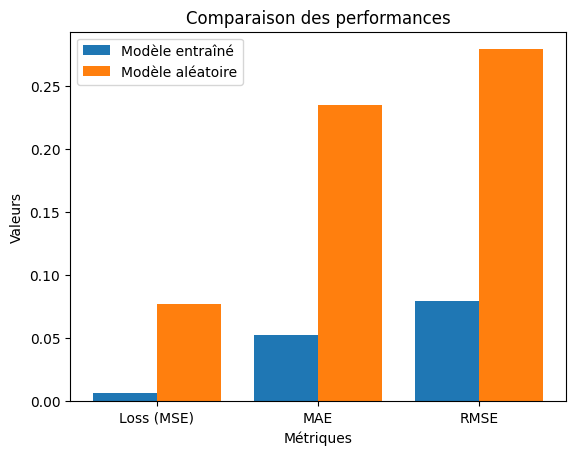

In [20]:
# Comparaison des métriques finales
import matplotlib.pyplot as plt

metrics = ['Loss (MSE)', 'MAE', 'RMSE']
trained_values = [test_loss / len(test_loader), mae, rmse]
random_values = [random_test_loss / len(test_loader), random_mae, random_rmse]

x = range(len(metrics))
plt.bar(x, trained_values, width=0.4, label='Modèle entraîné', align='center')
plt.bar([i + 0.4 for i in x], random_values, width=0.4, label='Modèle aléatoire', align='center')
plt.xlabel('Métriques')
plt.ylabel('Valeurs')
plt.title('Comparaison des performances')
plt.xticks([i + 0.2 for i in x], metrics)
plt.legend()
plt.show()